# Grad-CAM - Visualising Model Attention

Grad-CAM (Selvaraju et al. 2020) highlights which regions of the input image most influence the model's prediction.
For a clinical application like mammography screening, this is essential.
The model must be verified to focus on the lesion, not on imaging artefacts or patient labels burned into the DICOM.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.data.dataset import MammogramDataset
from src.data.preprocessing import preprocess
from src.evaluation.gradcam import TARGET_LAYERS, compute_gradcam
from src.evaluation.gradcam_roi import (
    centroid_distance,
    energy_pointing_game,
    heatmap_roi_iou,
    pointing_game,
)
from src.models import build_model


## Target Layers Per Architecture

Each model family has specific convolutional layer that produces the most informative Grad-CAM heatmaps.
Typically it is the last convolutional layer before the classification head.

In [2]:
for name, layer in TARGET_LAYERS.items():
    print(f"{name}: {layer}")

baseline: features.2.0
regularised: features.2.0
deeper: features.4.0
vgg16: backbone.features.28
vgg19: backbone.features.34
resnet50: backbone.layer4.2.conv3
efficientnet_b4: backbone.features.8


## Generating a heatmap

Two things are needed for this heatmap to be diagnostic rather than misleading:

1. **A trained model.** An *untrained* network has random weights, so Grad-CAM
   simply lights up the highest-contrast blob in the frame. In CBIS-DDSM that
   blob is the burned-in **"L CC" view marker** (the laterality/view film
   label), which is exactly the artefact the intro warns about. A trained
   checkpoint is therefore loaded below, not `pretrained=False` random weights.

2. **Preprocessing that removes the marker.** `preprocess` now segments the
   breast (largest connected component), zeroes the marker and background, and
   crops to the breast; see `src/data/preprocessing.py`. Without this the
   marker is the brightest object in the image and even a *trained* model can
   use it as a laterality/view shortcut instead of attending to the lesion.

The lesion **ROI** (green) is also overlaid to verify the heatmap lands on
the mass, along with the energy-in-ROI fraction.

In [3]:
IMAGE_ROOT = Path("../data/cbis-ddsm/cbis_ddsm")
VAL_CSV = Path("../data/cbis-ddsm/training/val.csv")
MODELS_DIR = Path("../models")

CANDIDATES = [
    ("baseline", "baseline", TARGET_LAYERS["baseline"]),
    ("regularised", "regularised", TARGET_LAYERS["regularised"]),
    ("vgg16_scratch", "vgg16", TARGET_LAYERS["vgg16"]),
    ("vgg16_imagenet", "vgg16", TARGET_LAYERS["vgg16"])
]

# Select the model for Grad-CAM visualisation
chosen = CANDIDATES[3]
run_name, model_name, target_layer = chosen

model = build_model(model_name, pretrained=False)
model.load_state_dict(torch.load(MODELS_DIR / f"{run_name}.pt", map_location=torch.device("cpu")))
print(f"Loaded model checkpoint: {run_name} ({model_name})")
model.eval()

ds = MammogramDataset(VAL_CSV, IMAGE_ROOT, transform=preprocess)
mal = [i for i in range(len(ds)) if ds.df.iloc[i]["label"] == 1]
sample_idx, roi_mask = None, None
for i in mal:
    r = ds.load_roi(i, (224, 224))
    if r is not None and r.sum() > 0:
        sample_idx = i
        roi_mask = r
        break

image_id = str(ds.df.iloc[sample_idx]["image_id"])
img_arr = preprocess(IMAGE_ROOT / f"{image_id}.dcm", image_size=224, use_clahe=True)

input_tensor = torch.from_numpy(img_arr).unsqueeze(0).unsqueeze(0)
heatmap = compute_gradcam(model, input_tensor, target_layer_name=target_layer)

print(f"Sample index: {sample_idx}, Image ID: {image_id}")
print(f"Heatmap shape: {heatmap.shape}")
print(f"Heat map min: {heatmap.min():.3f}, max: {heatmap.max():.3f}")


Loaded model checkpoint: vgg16_imagenet (vgg16)
Sample index: 0, Image ID: Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/e35e53fd-5312-406e-ad9f-4c11e725e53f
Heatmap shape: (224, 224)
Heat map min: 0.000, max: 1.000


## Visualising the overlay

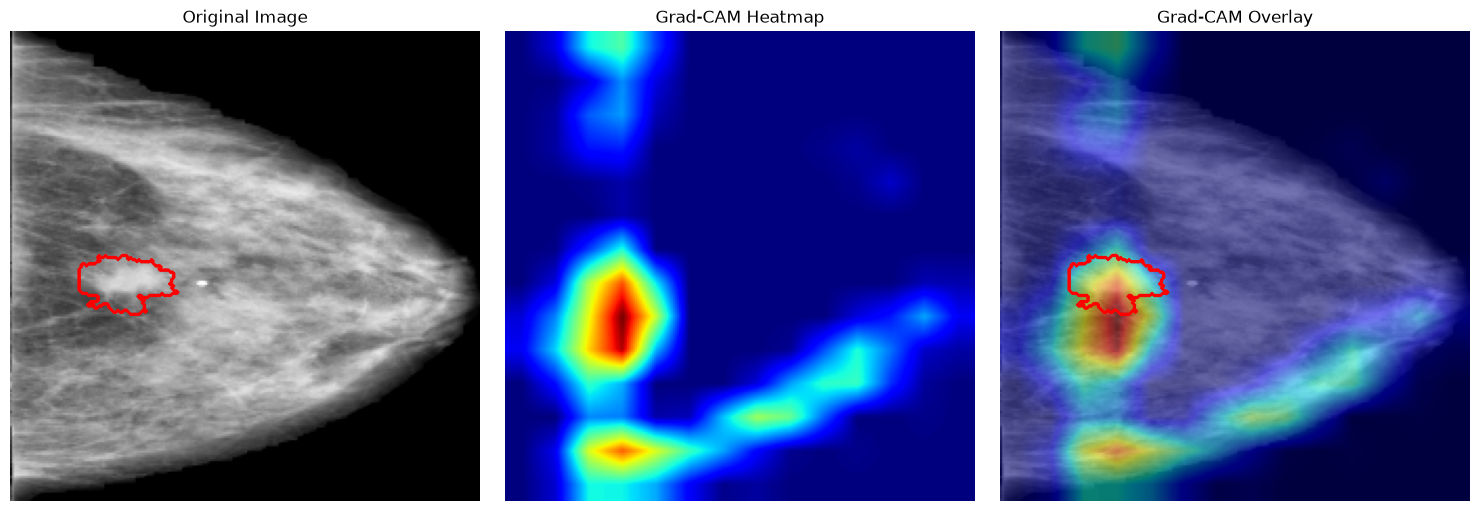

In [4]:
has_roi = roi_mask is not None and roi_mask.sum() > 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_arr, cmap="gray")
axes[0].set_title("Original Image")
if has_roi:
    axes[0].contour(roi_mask, colors="r", linewidths=1)
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(img_arr, cmap="gray")
axes[2].imshow(heatmap, cmap="jet", alpha=0.5)
if has_roi:
    axes[2].contour(roi_mask, colors="r", linewidths=1)
axes[2].set_title("Grad-CAM Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Quantitative Grad-CAM vs ROI

When ground-truth lesion masks (ROIs) are available, it is possible to **quantify** whether the model is looking at the right place.

Four metrics are computed:

| Metric                   | What it measures                         |
|--------------------------|------------------------------------------|
| Pointing game            | Does the hottest pixel fall in the ROI?  |
| Energy-based pointing    | Fraction of heatmap energy inside ROI    |
| Heatmap-ROI IoU          | Spatial overlap (thresholded heatmap)    |
| Centroid distance        | How far apart are the attention centres? |

In [5]:
# Synthetic example: 224×224 heatmap with a hot spot, and a small ROI
cam = np.zeros((224, 224), dtype=np.float32)
cam[100:130, 100:130] = 1.0 # hot region

roi = np.zeros((224, 224), dtype=np.uint8)
roi[105:125, 105:125] = 1 # ground-truth lesion (mostly overlapping)

print(f"Pointing game:\t\t{pointing_game(cam, roi)}")
print(f"Energy fraction:\t{energy_pointing_game(cam, roi):.3f}")
print(f"IoU:\t\t\t{heatmap_roi_iou(cam, roi):.3f}")
print(f"Centroid dist:\t\t{centroid_distance(cam, roi):.3f}")


Pointing game:		False
Energy fraction:	0.444
IoU:			0.444
Centroid dist:		0.000
